<a href="https://colab.research.google.com/github/dangchicong/hocsau/blob/main/Do_an.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cài đặt thư viện kaggle
!pip install kaggle

# Upload file kaggle.json (lấy từ Settings trong hồ sơ Kaggle của bạn)
from google.colab import files
files.upload()

# Cấu hình thư mục chứa key
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Lệnh tải dataset Fashion MNIST
!kaggle datasets download -d zalando-research/fashionmnist

# Giải nén
!unzip fashionmnist.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/zalando-research/fashionmnist
License(s): other
100% 68.8M/68.8M [00:00<00:00, 114MB/s]

Archive:  fashionmnist.zip
  inflating: fashion-mnist_test.csv  
  inflating: fashion-mnist_train.csv  
  inflating: t10k-images-idx3-ubyte  
  inflating: t10k-labels-idx1-ubyte  
  inflating: train-images-idx3-ubyte  
  inflating: train-labels-idx1-ubyte  


Khai báo siêu tham số

In [ ]:
# KHAI BÁO SIÊU THAM SỐ
learning_rate = 0.001  #[cite: 1, 6]
batch_size = 32        #[cite: 1]
epochs = 20           #[cite: 1]
optimizer_name = 'Adam' #
loss_function = 'sparse_categorical_crossentropy' #[cite: 1, 6]

# Áp dụng vào quá trình biên dịch mô hình
from tensorflow.keras import optimizers

model.compile(
    optimizer=optimizers.Adam(learning_rate=learning_rate),
    loss=loss_function,
    metrics=['accuracy']
)

Chuẩn hóa dữ liệu, Kết quả (60000, 784) xác nhận đã load thành công 60.000 mẫu dữ liệu, mỗi mẫu là một ảnh phẳng có 784 điểm ảnh. Với cấu hình RAM 16GB, chúng ta sẽ tiến hành xây dựng mô hình MLP theo đúng các yêu cầu  của đề cương đồ án


In [2]:
import pandas as pd
import numpy as np

# 1. Đọc dữ liệu từ file CSV đã giải nén
train_data = pd.read_csv('fashion-mnist_train.csv')
test_data = pd.read_csv('fashion-mnist_test.csv')

# 2. Tách nhãn (y) và dữ liệu hình ảnh (X)
X_train = train_data.iloc[:, 1:].values
y_train = train_data.iloc[:, 0].values
X_test = test_data.iloc[:, 1:].values
y_test = test_data.iloc[:, 0].values

# 3. Chuẩn hóa dữ liệu về khoảng [0, 1]
# Đây là yêu cầu quan trọng để Gradient Descent chạy tốt trên CPU
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Kích thước tập train:", X_train.shape)
print("Dữ liệu đã sẵn sàng!")

Kích thước tập train: (60000, 784)
Dữ liệu đã sẵn sàng!


Xây dựng cấu trúc mạng MLP

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Khởi tạo mô hình tuần tự[cite: 2]
model = models.Sequential([
    # Lớp đầu vào: 784 nơ-ron tương ứng với kích thước ảnh[cite: 2]
    layers.Input(shape=(784,)),

    # Lớp ẩn thứ nhất: 256 nơ-ron + ReLU
    layers.Dense(256, activation='relu'),
    # Dropout 20% để chống Overfitting theo yêu cầu đề cương
    layers.Dropout(0.2),

    # Lớp ẩn thứ hai: 128 nơ-ron + ReLU
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),

    # Lớp đầu ra: 10 nơ-ron cho 10 loại quần áo + Softmax[cite: 2, 6]
    layers.Dense(10, activation='softmax')
])

# Biên dịch mô hình với các siêu tham số đã biện luận[cite: 1, 6]
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary() # Hiển thị bảng tóm tắt thông số để đưa vào báo cáo

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

Huấn luyện mô hình

In [4]:
# Bắt đầu huấn luyện[cite: 1, 2]
history = model.fit(
    X_train, y_train,
    epochs=20,            # Số lượt huấn luyện đã chọn
    batch_size=32,        # Kích thước lô phù hợp CPU[cite: 1]
    validation_split=0.2, # Tách 20% để kiểm định (Validation)[cite: 6]
    verbose=1
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.7941 - loss: 0.5678 - val_accuracy: 0.8490 - val_loss: 0.4127
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8463 - loss: 0.4238 - val_accuracy: 0.8678 - val_loss: 0.3706
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8584 - loss: 0.3880 - val_accuracy: 0.8685 - val_loss: 0.3676
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.8671 - loss: 0.3638 - val_accuracy: 0.8769 - val_loss: 0.3442
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8733 - loss: 0.3475 - val_accuracy: 0.8769 - val_loss: 0.3380
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8774 - loss: 0.3320 - val_accuracy: 0.8767 - val_loss: 0.3353
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8805 - loss: 0.3222 - val_accuracy: 0.8790 - val_loss: 0.3310
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8830 - loss: 0

Vẽ biểu đồ Accuracy và Loss

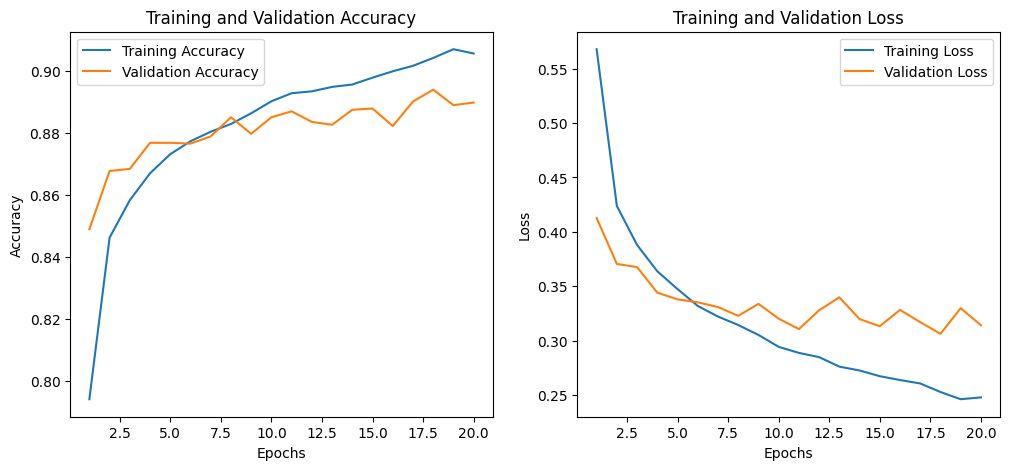

In [5]:
import matplotlib.pyplot as plt

# Lấy dữ liệu từ biến history[cite: 1]
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

# Vẽ biểu đồ Accuracy Curve
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Vẽ biểu đồ Loss Curve
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

Đánh giá trên tập Test

In [6]:
# Chuyển sang chế độ suy luận và đánh giá[cite: 6]
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Độ chính xác trên tập Test: {test_acc*100:.2f}%")

Độ chính xác trên tập Test: 89.00%


Xuất các chỉ số đánh giá chuyên sâu

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Báo cáo phân loại chi tiết:
              precision    recall  f1-score   support

           0       0.79      0.88      0.83      1000
           1       0.98      0.99      0.99      1000
           2       0.84      0.81      0.82      1000
           3       0.94      0.89      0.91      1000
           4       0.77      0.91      0.83      1000
           5       0.98      0.94      0.96      1000
           6       0.77      0.61      0.68      1000
           7       0.92      0.96      0.94      1000
           8       0.98      0.97      0.97      1000
           9       0.95      0.95      0.95      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



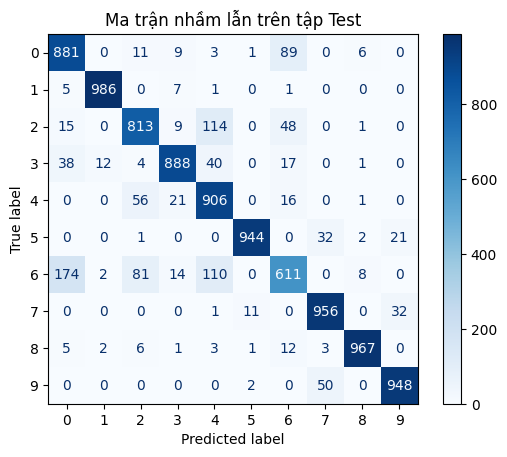

In [9]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Dự đoán nhãn trên tập test (Chế độ suy luận)
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# 1. Tính Precision, Recall, F1-score[cite: 6]
print("Báo cáo phân loại chi tiết:")
print(classification_report(y_test, y_pred))

# 2. Vẽ Ma trận nhầm lẫn (Confusion Matrix)[cite: 6]
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Ma trận nhầm lẫn trên tập Test')
plt.show()